In [22]:
from catalog_manager.make_system_dicts_new import Sampler, SamplingInputs,  RedshiftsVelDispModes, MainLensModes, SecondaryLensModes, SubStrucModes, SourceModes, SourcePosModes
import numpy as np
from config import CATALOGS_DIR
sampling_inputs = SamplingInputs(

        # ThetaE_min   = 1.0,
        # ThetaE_max   = 2.0,
        z_min=0.0,
        z_max=5.0,
        prior_lens_ThetaE=[0.5, 2.5],

        prior_lens_orient=[0, 2.* np.pi],
        prior_lens_pos=[-1.0, 1.0],
        prior_lens_q= [0.9, 1.0],
        prior_lens_slope_normal=[1.0, 0.1],
        prior_lens_VelDisp = [50, 400],
    
        prior_sub_max_n = 1,
        prior_sub_pos= [- 3.0, + 3.0 ],
        prior_sub_log_mass= [6., 7.],

        prior_source_I = 1e-13,         #if only one number, is fixed
        prior_source_std_main = 0.8, #kpc,
        prior_source_frac_of_theta_pos= 0.3,
        prior_source_orient= 0.,
        prior_source_q = 1. ,

        prior_shear_d = [0., np.pi],
        prior_shear_s = [0., 0.1]
    )



My_Pypeline = [
    RedshiftsVelDispModes.RESAMPLE_THETA,
    MainLensModes.PEMD,
    SecondaryLensModes.EXTERNAL_SHEAR,
    SubStrucModes.NFW_subs_FIXED_R_MAX,
    SourceModes.GAUSS_SOURCE,
    SourcePosModes.RAND_FRAC_THETA_E

]

   

full_sys_conf = Sampler(
    My_Pypeline,
    sampling_inputs,
    N_samples=100,
    cat_name="test2"
)



#now we have to test if everything is fine in the configuration file for the lensing model to run




from deep_learning import NoNoiseDataset, custom_dataloader

dataset = NoNoiseDataset(
    catalog_name = 'test2',
    grid_pixel_side = 100, 
    grid_width_arcsec = 10.,
    broadcasting= True ,
)

dataloader = custom_dataloader(dataset, 2)

iterator = iter(dataloader)



Flat catalog written to /home/francesco/Desktop/master_thesis_git_clean/master_thesis_code/catalogs/test2.pth
Sampling configuration written to /home/francesco/Desktop/master_thesis_git_clean/master_thesis_code/catalogs/sampling_configs/test2.pth
Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
tensor(100)


In [23]:
from noise_applicator.noisers.base_noiser import EuclidNoiser
noiser = EuclidNoiser(device="cuda")

max exponential = 0.9872280359268188, max of the I tensor is 9.9999998245167e-14
max image = 9.87228013097155e-14


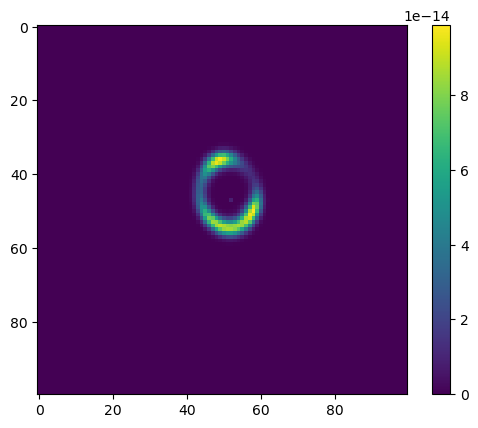

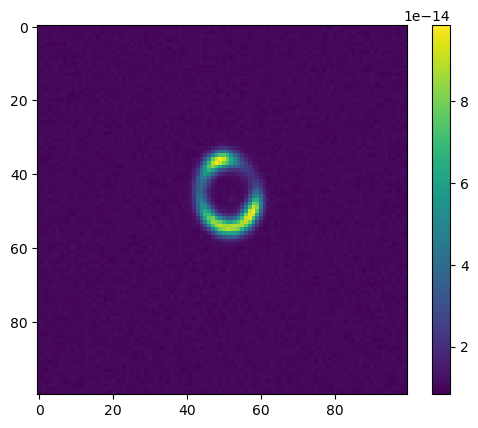

In [24]:
import matplotlib.pyplot as plt
import torch


image = next(iterator)[0]

print(f"max image = {torch.max(image)}")
plt.imshow(image.cpu().numpy()[0][0])
plt.colorbar()
plt.show() 

image = noiser(image)


plt.imshow(image.cpu().numpy()[0][0])
plt.colorbar()
plt.show() 



In [6]:
import pandas as pd

dict_conf = full_sys_conf.get_pth()

def tensor_dict_to_dataframes(nested_dict):
    dfs = {}
    for key, subdict in nested_dict.items():
        # top‐level component, e.g. flat['precomputed']
        if isinstance(subdict, dict) and 'params' in subdict and 'param_map' in subdict:
            arr = subdict['params'].cpu().numpy()
            dfs[key] = pd.DataFrame(arr, columns=subdict['param_map'])
        # second level, e.g. flat['mass_components']['PEMD']
        elif isinstance(subdict, dict):
            for subkey, inner in subdict.items():
                if isinstance(inner, dict) and 'params' in inner and 'param_map' in inner:
                    arr = inner['params'].cpu().numpy()
                    name = f"{key}_{subkey}"
                    dfs[name] = pd.DataFrame(arr, columns=inner['param_map'])
    return dfs


dfs = tensor_dict_to_dataframes(dict_conf)

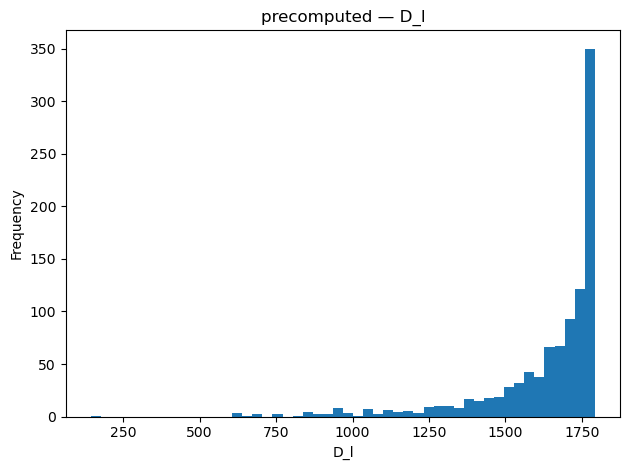

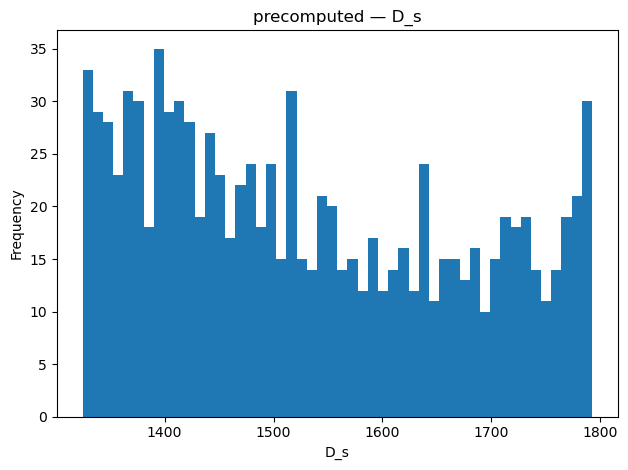

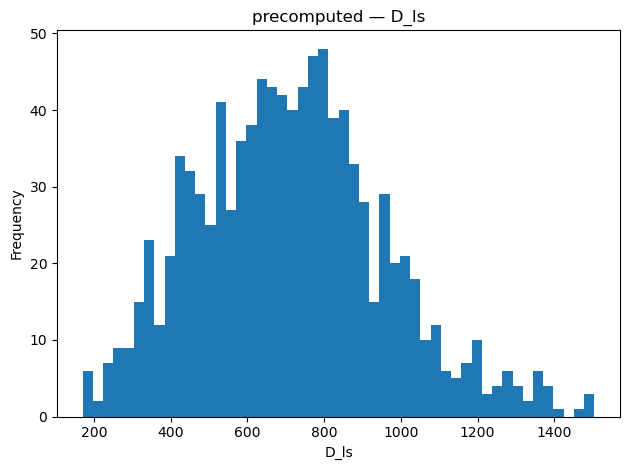

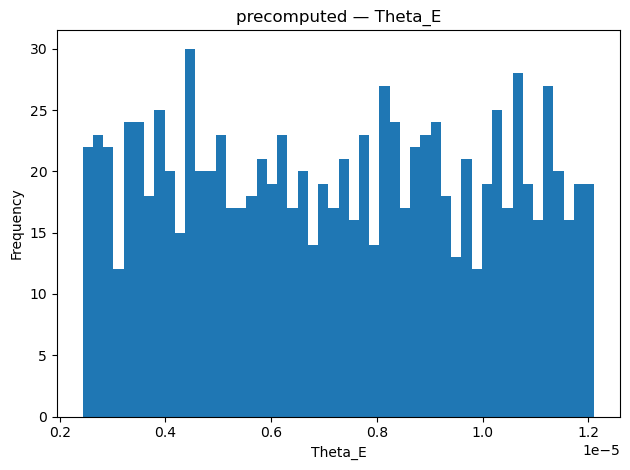

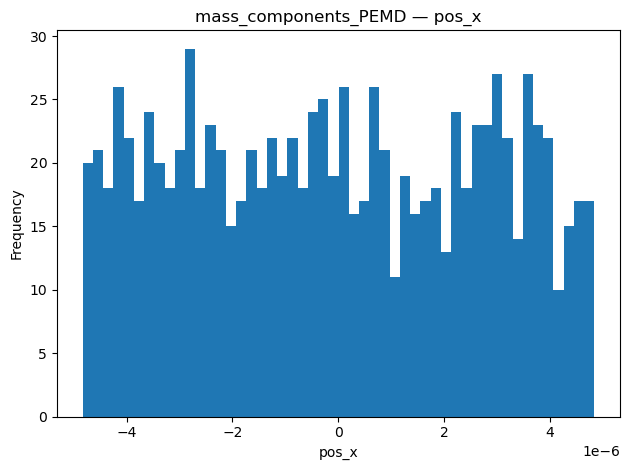

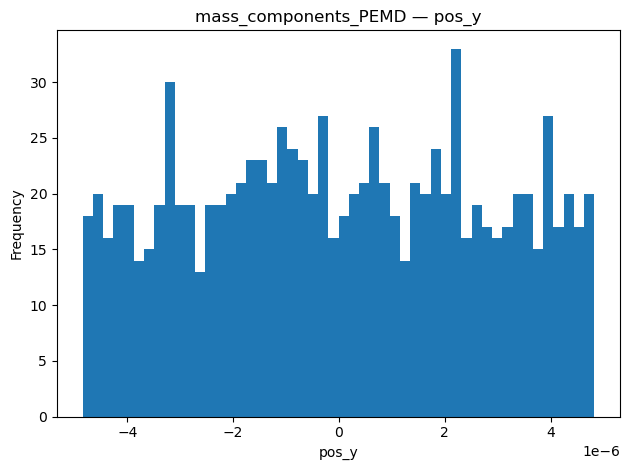

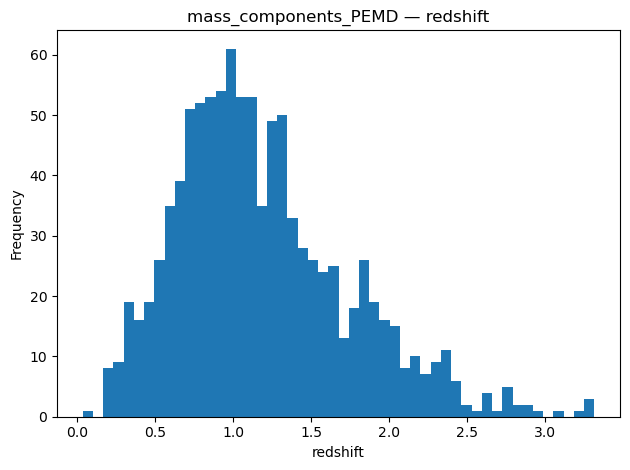

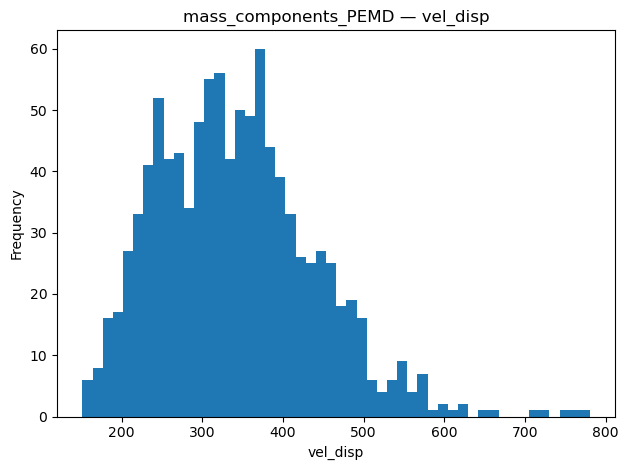

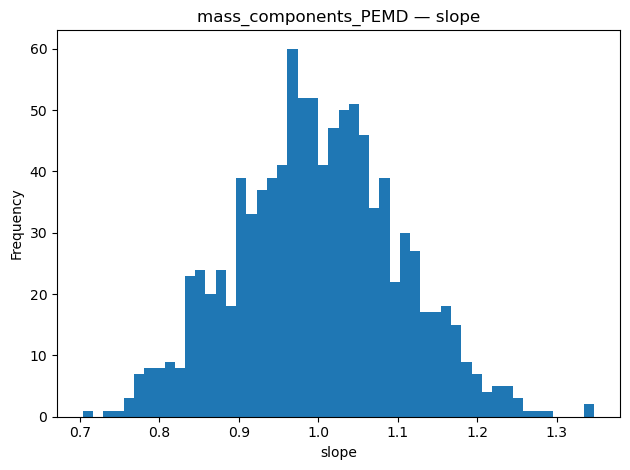

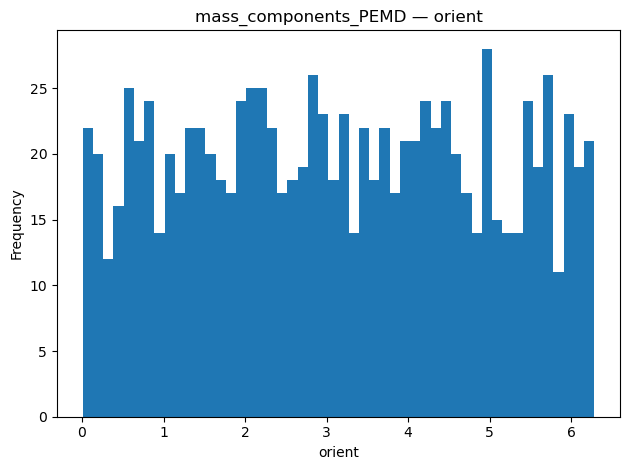

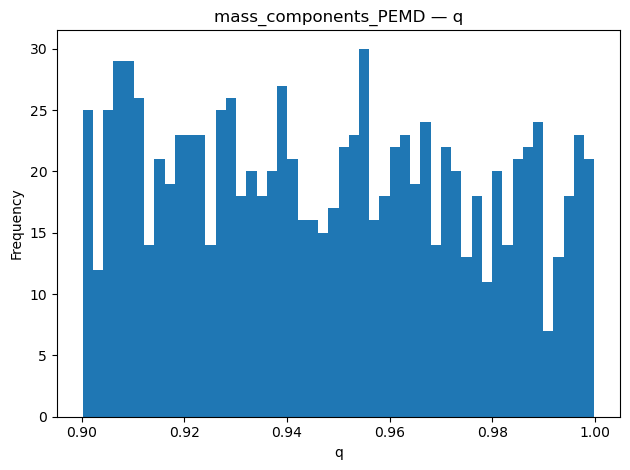

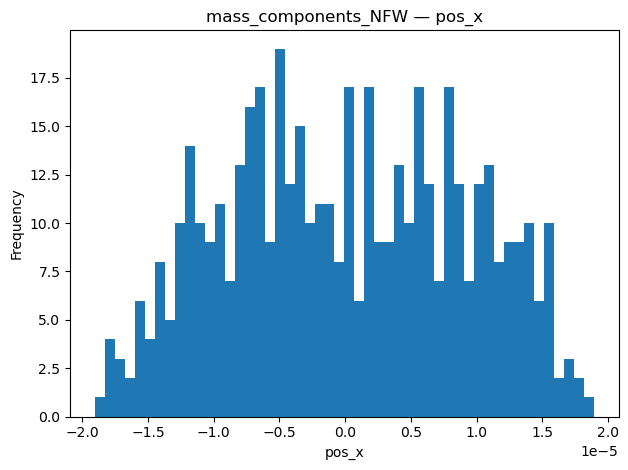

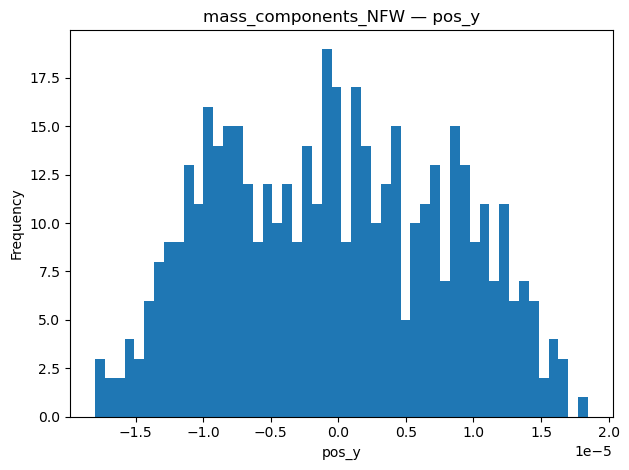

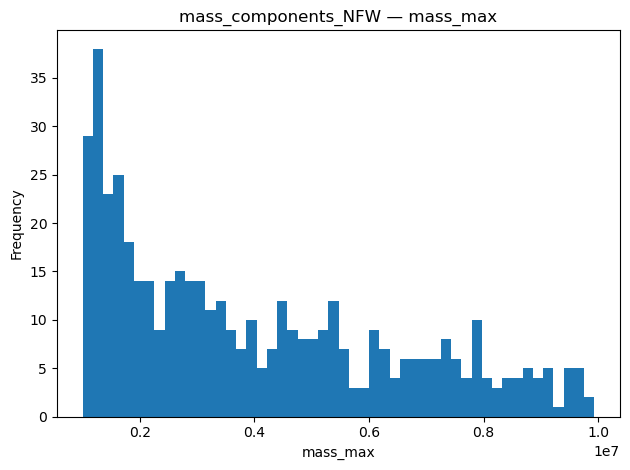

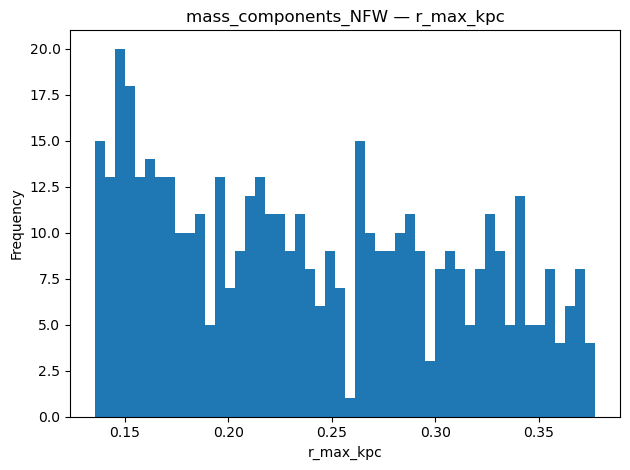

Skipping mass_components_NFW.redshift — all values are non-finite.


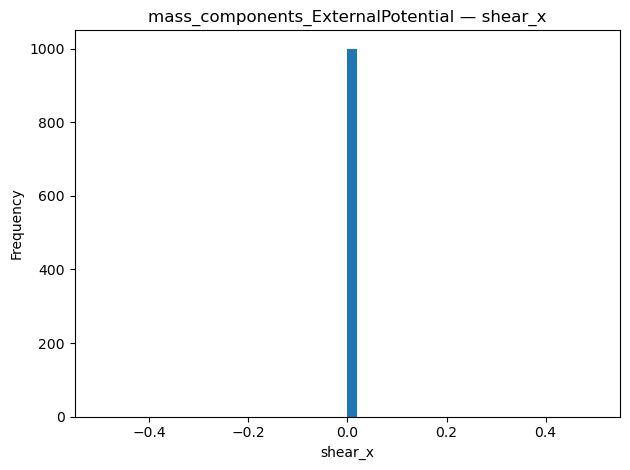

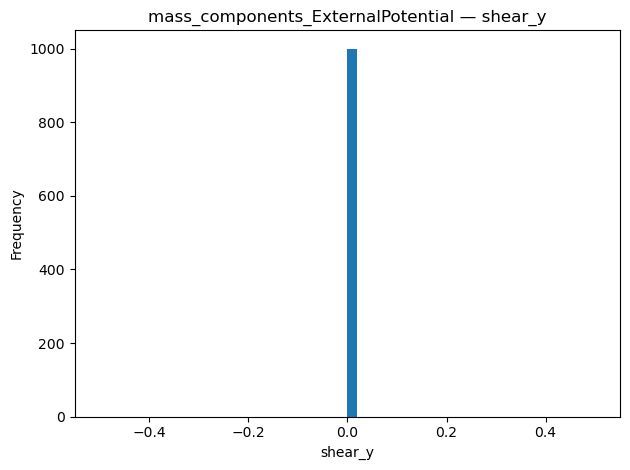

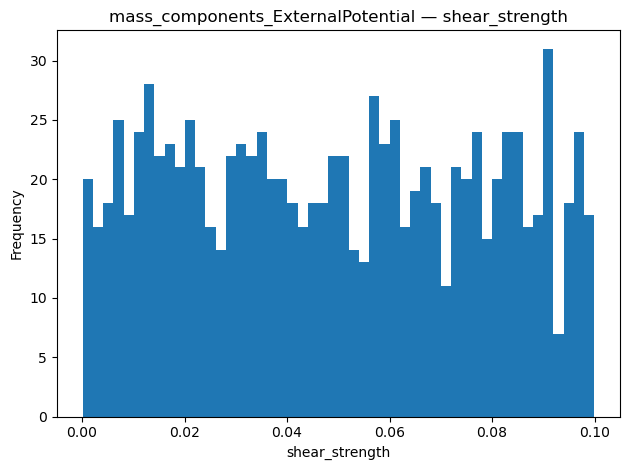

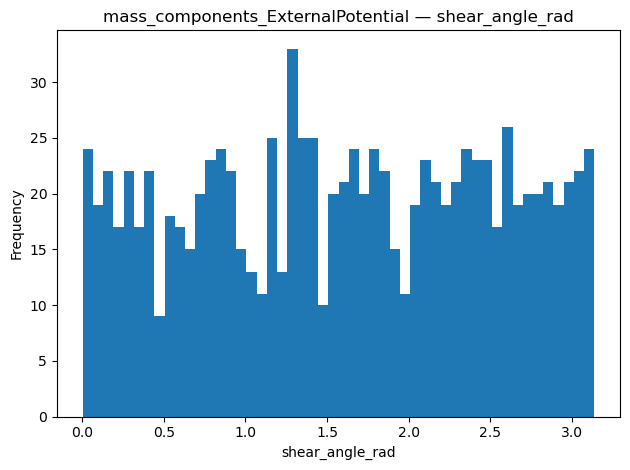

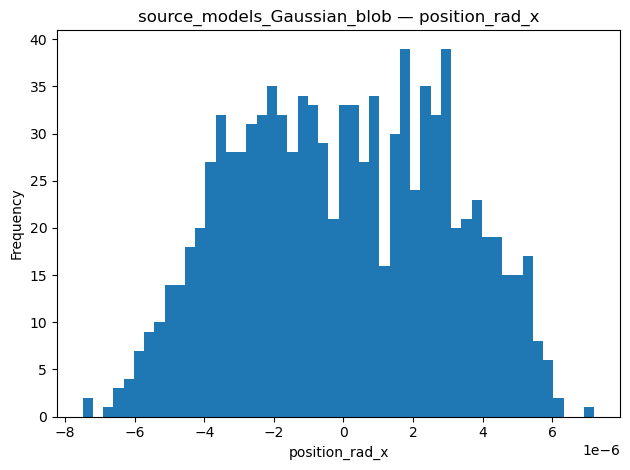

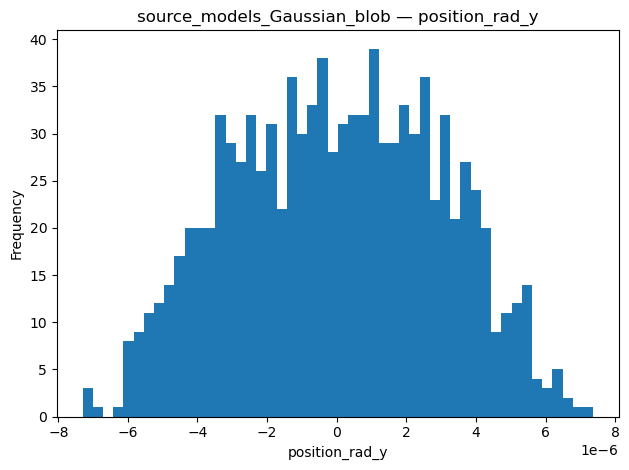

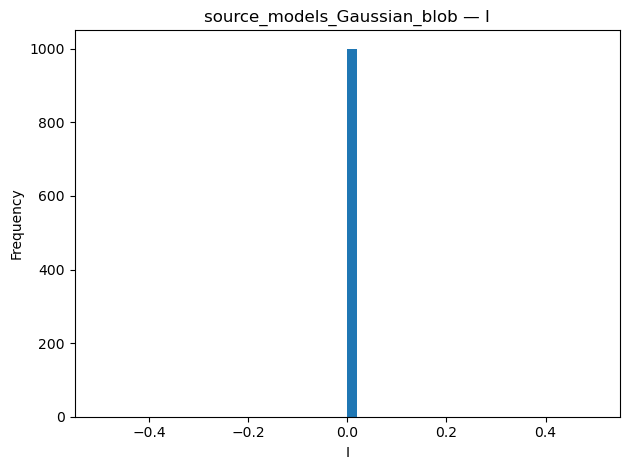

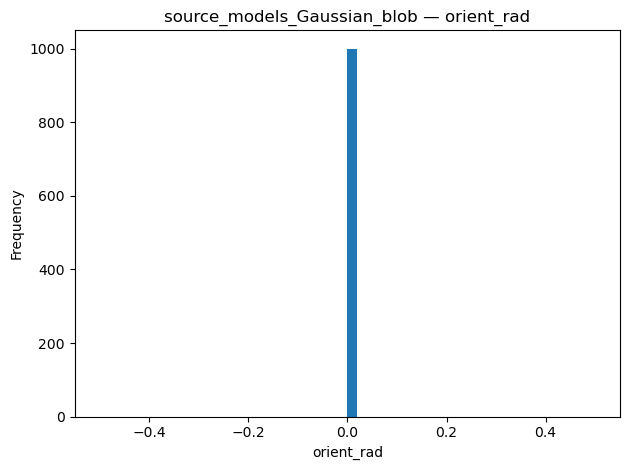

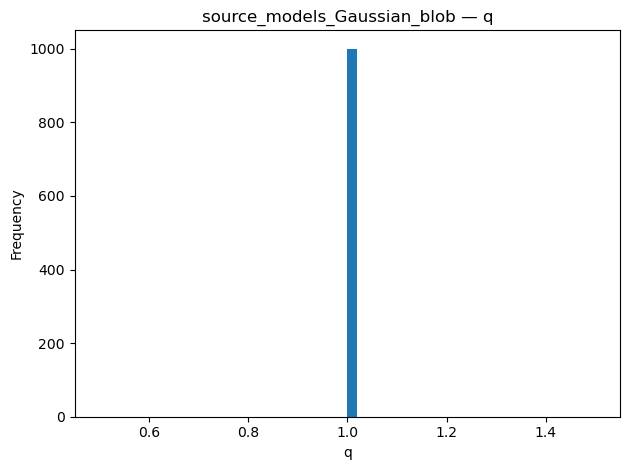

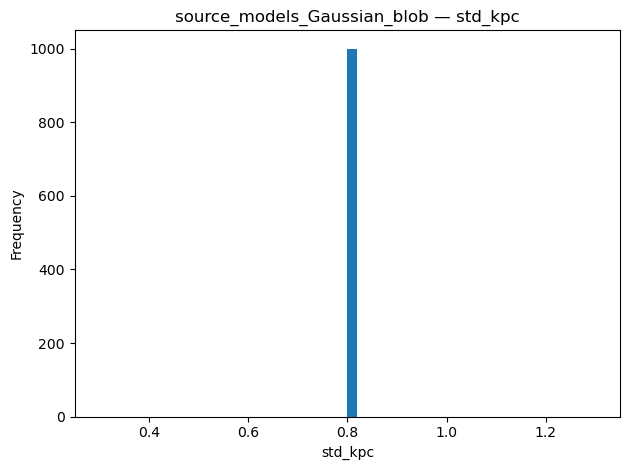

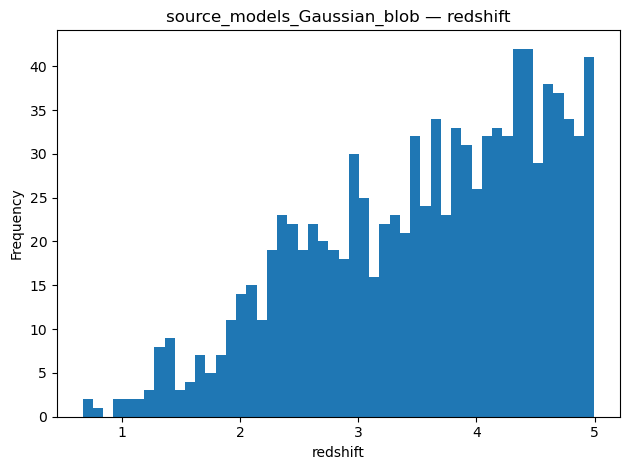

In [7]:
import matplotlib.pyplot as plt
import numpy as np

for name, df in dfs.items():
    for col in df.columns:
        values = df[col].values
        finite_vals = values[np.isfinite(values)]
        if len(finite_vals) == 0:
            print(f"Skipping {name}.{col} — all values are non-finite.")
            continue
        plt.figure()
        plt.hist(finite_vals, bins=50)
        plt.title(f"{name} — {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
